# Сравнение устойчивости ResNet-18 и ViT-tiny к FGSM


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Класс атаки

Единый интерфейс `attack(model, x, y) -> x_adv`. Модель всегда принимает вход в `[0, 1]` — нормализация (если нужна) встроена в саму модель, а не в атаку. Такой же интерфейс будет у `PGDAttack` и остальных, когда дойдёт очередь — просто копируется структура.

In [11]:
class FGSMAttack:
    def __init__(self, epsilon):
        self.epsilon = epsilon

    def __call__(self, model, x, y):
        x = x.clone().detach().requires_grad_(True)
        loss = F.cross_entropy(model(x), y)
        grad = torch.autograd.grad(loss, x)[0]
        x_adv = x + self.epsilon * grad.sign()
        return x_adv.clamp(0, 1).detach()


class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, -1, 1, 1))
        self.register_buffer("std",  torch.tensor(std).view(1, -1, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class NormalizedModel(nn.Module):
    """Оборачивает уже обученную модель, добавляя нормализацию на входе.
    Нужно моделям, которые обучались с нормализацией в трансформах датасета (как ViT) —
    чтобы они, как и ResNet (у него нормализация уже была внутри forward), тоже
    принимали чистый [0, 1] вход и работали с одним и тем же классом атаки."""
    def __init__(self, model, mean, std):
        super().__init__()
        self.normalize = Normalize(mean, std)
        self.model = model

    def forward(self, x):
        return self.model(self.normalize(x))

## Загрузка моделей


In [12]:
VIT_WEIGHTS_PATH = '../input/datasets/notquartzz/weights-aa/vit_t_cifar10.pth'
RESNET_WEIGHTS_PATH = '../input/datasets/notquartzz/weights-aa/resnet18_cifar10.pth'

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10,
                 mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)):
        super().__init__()
        self.normalize = Normalize(mean, std)
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], 1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.normalize(x)
        out = F.relu(self.bn1(self.conv1(out)))
        out = self.layer1(out); out = self.layer2(out)
        out = self.layer3(out); out = self.layer4(out)
        out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return self.linear(out)


resnet_raw = ResNetCIFAR(BasicBlock, [2, 2, 2, 2], num_classes=10)
def strip_module_prefix(state_dict, prefix="model."):
    return {
        (k[len(prefix):] if k.startswith(prefix) else k): v
        for k, v in state_dict.items()
    }

resnet_state = strip_module_prefix(torch.load(RESNET_WEIGHTS_PATH, map_location="cpu", weights_only=True))
resnet_raw.load_state_dict(resnet_state)
resnet_model = resnet_raw.to(device).eval()
VIT_MEAN = (0.4914, 0.4822, 0.4465)
VIT_STD  = (0.2023, 0.1994, 0.2010)
vit_raw = timm.create_model(
    'vit_tiny_patch16_224', pretrained=False,
    num_classes=10, in_chans=3, img_size=32, patch_size=4
)
vit_state = strip_module_prefix(torch.load(VIT_WEIGHTS_PATH, map_location="cpu", weights_only=True))
vit_raw.load_state_dict(vit_state)
vit_model = NormalizedModel(vit_raw, mean=VIT_MEAN, std=VIT_STD).to(device).eval()

models = {"resnet18": resnet_model, "vit_tiny": vit_model}

## Загрузка датасета

Без нормализации в трансформах — модели теперь сами нормализуют вход. `shuffle=False`: обе модели видят одни и те же картинки в одном порядке.

In [13]:
torch.manual_seed(42)

transform = transforms.Compose([transforms.ToTensor()])
test_set = torchvision.datasets.CIFAR10(root='/kaggle/input/datasets/pankrzysiu/cifar10-python', train=False, download=False, transform=transform)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ("airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

## Прогон атаки для обеих моделей

In [14]:
def evaluate_robust_accuracy(model, attack, loader, device, max_examples=5):
    model.eval()
    correct = total = 0
    saved_examples = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack(model, x, y)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        if len(saved_examples) < max_examples:
            wrong_idx = (preds != y).nonzero(as_tuple=True)[0]
            for idx in wrong_idx[: max_examples - len(saved_examples)]:
                saved_examples.append((y[idx].item(), preds[idx].item(), x_adv[idx].detach().cpu().numpy()))
    return correct / total, saved_examples


EPS_LIST = [0, 1, 2, 4, 8, 16]

results = {name: [] for name in models}
examples = {name: {} for name in models}

for name, m in models.items():
    for eps_num in EPS_LIST:
        attack = FGSMAttack(epsilon=eps_num / 255)
        acc, ex = evaluate_robust_accuracy(m, attack, test_loader, device)
        results[name].append(acc)
        examples[name][eps_num] = ex
        print(f"{name:>10} | eps={eps_num:>2}/255 -> accuracy {acc*100:5.2f}%")

  resnet18 | eps= 0/255 -> accuracy 93.47%
  resnet18 | eps= 1/255 -> accuracy 52.21%
  resnet18 | eps= 2/255 -> accuracy 29.37%
  resnet18 | eps= 4/255 -> accuracy 16.11%
  resnet18 | eps= 8/255 -> accuracy 10.47%
  resnet18 | eps=16/255 -> accuracy  7.66%
  vit_tiny | eps= 0/255 -> accuracy 80.58%
  vit_tiny | eps= 1/255 -> accuracy 47.68%
  vit_tiny | eps= 2/255 -> accuracy 23.90%
  vit_tiny | eps= 4/255 -> accuracy  7.37%
  vit_tiny | eps= 8/255 -> accuracy  2.86%
  vit_tiny | eps=16/255 -> accuracy  3.92%


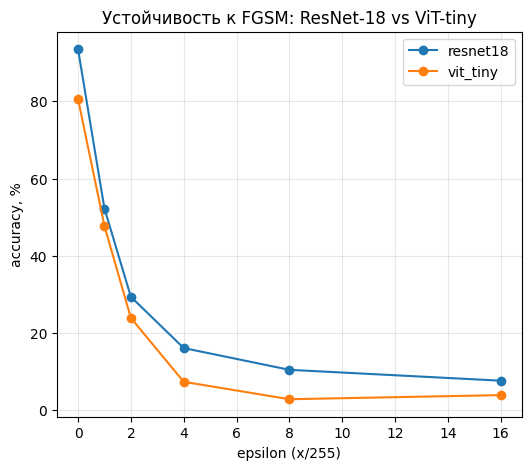

In [15]:
plt.figure(figsize=(6, 5))
for name, accs in results.items():
    plt.plot(EPS_LIST, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("epsilon (x/255)")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к FGSM: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Логирование

Итоговая таблица (robust accuracy по каждой модели и eps):


,eps (x/255),resnet18,vit_tiny
0,0,0.9347,0.8058
1,1,0.5221,0.4768
2,2,0.2937,0.2390
3,4,0.1611,0.0737
4,8,0.1047,0.0286
5,16,0.0766,0.0392


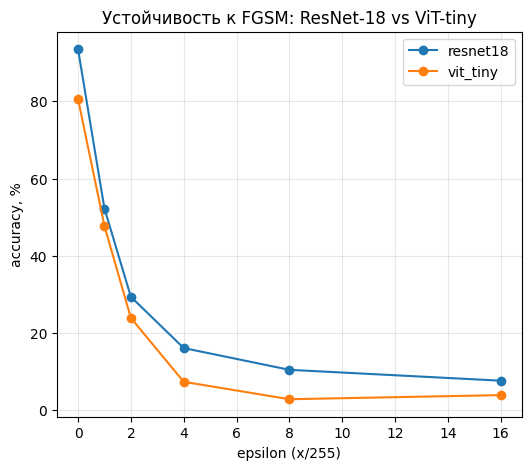

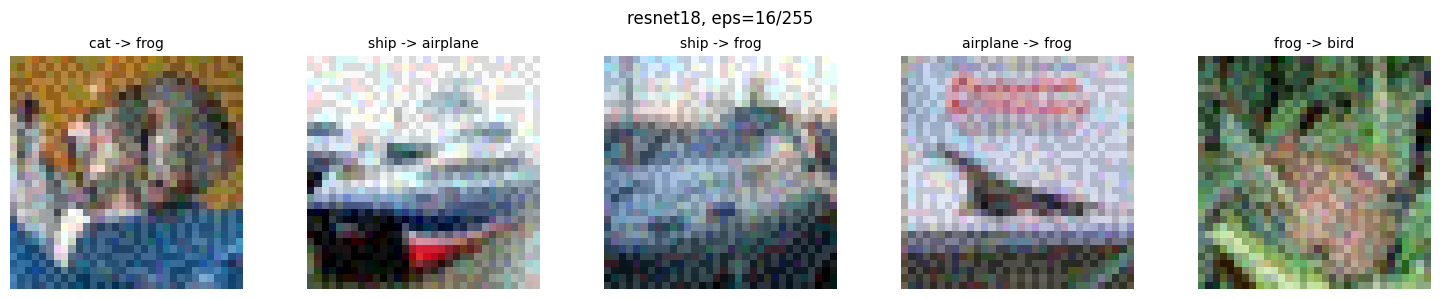

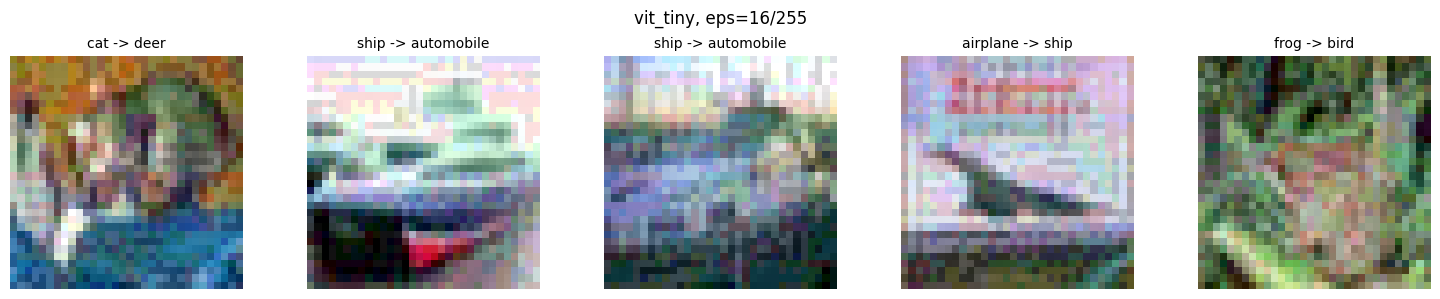

In [16]:

summary_df = pd.DataFrame({"eps (x/255)": EPS_LIST, **results})
print("Итоговая таблица (robust accuracy по каждой модели и eps):")
display(summary_df)

fig = plt.figure(figsize=(6, 5))
for name, accs in results.items():
    plt.plot(EPS_LIST, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("epsilon (x/255)")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к FGSM: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

example_figs = {}
for name in models:
    ex_list = examples[name][EPS_LIST[-1]]
    if not ex_list:
        continue
    ex_fig, axes = plt.subplots(1, len(ex_list), figsize=(3 * len(ex_list), 3))
    axes = [axes] if len(ex_list) == 1 else axes
    for ax, (true_label, pred_label, img) in zip(axes, ex_list):
        ax.imshow(np.transpose(img, (1, 2, 0)).clip(0, 1))
        ax.set_title(f"{CLASSES[true_label]} -> {CLASSES[pred_label]}", fontsize=10)
        ax.axis("off")
    ex_fig.suptitle(f"{name}, eps={EPS_LIST[-1]}/255")
    plt.tight_layout()
    plt.show()
    example_figs[name] = ex_fig


# try:
#     from clearml import Task

#     task = Task.init(project_name="adversarial-attacks", task_name="fgsm-resnet-vs-vit")
#     logger = task.get_logger()

#     for name, accs in results.items():
#         for eps_num, acc in zip(EPS_LIST, accs):
#             logger.report_scalar(title="robust_accuracy_vs_eps", series=name, iteration=eps_num, value=acc)

#     logger.report_table(title="fgsm_comparison", series="summary", iteration=0, table_plot=summary_df)
#     logger.report_matplotlib_figure(title="accuracy_vs_epsilon", series="comparison", figure=fig, iteration=0)
#     for name, ex_fig in example_figs.items():
#         logger.report_matplotlib_figure(title="adversarial_examples", series=name, figure=ex_fig, iteration=0)

#     print("\nРезультаты также залогированы в ClearML (project: adversarial-attacks).")
# except Exception as e:
#     print(f"\nClearML недоступен ({e}) — результаты выше видны локально в ноутбуке, в общий дашборд не ушли.")


## PGD-атака

Многошаговый вариант FGSM: несколько маленьких шагов градиента вместо одного большого, с проекцией обратно в тот же epsilon-шар после каждого шага. Тот же список `EPS_LIST`, что и у FGSM — можно сравнить напрямую, на сколько многошаговая атака сильнее одношаговой при одинаковом бюджете `epsilon`.

In [17]:
class PGDAttack:
    def __init__(self, epsilon, alpha=None, num_steps=10):
        self.epsilon = epsilon
        self.alpha = alpha if alpha is not None else epsilon / 4  # стандартный выбор шага
        self.num_steps = num_steps

    def __call__(self, model, x, y):
        x_orig = x.clone().detach()
        # случайный старт внутри epsilon-шара — иначе это была бы просто FGSM,
        # повторённая много раз подряд из одной и той же точки
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-self.epsilon, self.epsilon)
        x_adv = x_adv.clamp(0, 1).detach()

        for _ in range(self.num_steps):
            x_adv.requires_grad_(True)
            loss = F.cross_entropy(model(x_adv), y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv.detach() + self.alpha * grad.sign()
            # проекция обратно в epsilon-шар вокруг оригинала
            x_adv = torch.max(torch.min(x_adv, x_orig + self.epsilon), x_orig - self.epsilon)
            x_adv = x_adv.clamp(0, 1).detach()

        return x_adv

## Прогон PGD-атаки для обеих моделей

In [18]:
pgd_results = {name: [] for name in models}
pgd_examples = {name: {} for name in models}

for name, m in models.items():
    for eps_num in EPS_LIST:
        attack = PGDAttack(epsilon=eps_num / 255, num_steps=10)
        acc, ex = evaluate_robust_accuracy(m, attack, test_loader, device)
        pgd_results[name].append(acc)
        pgd_examples[name][eps_num] = ex
        print(f"{name:>10} | eps={eps_num:>2}/255 -> accuracy {acc*100:5.2f}%")

  resnet18 | eps= 0/255 -> accuracy 93.47%
  resnet18 | eps= 1/255 -> accuracy 34.78%
  resnet18 | eps= 2/255 -> accuracy  4.53%
  resnet18 | eps= 4/255 -> accuracy  0.09%
  resnet18 | eps= 8/255 -> accuracy  0.00%
  resnet18 | eps=16/255 -> accuracy  0.00%
  vit_tiny | eps= 0/255 -> accuracy 80.58%
  vit_tiny | eps= 1/255 -> accuracy 44.54%
  vit_tiny | eps= 2/255 -> accuracy 15.82%
  vit_tiny | eps= 4/255 -> accuracy  1.04%
  vit_tiny | eps= 8/255 -> accuracy  0.00%
  vit_tiny | eps=16/255 -> accuracy  0.00%


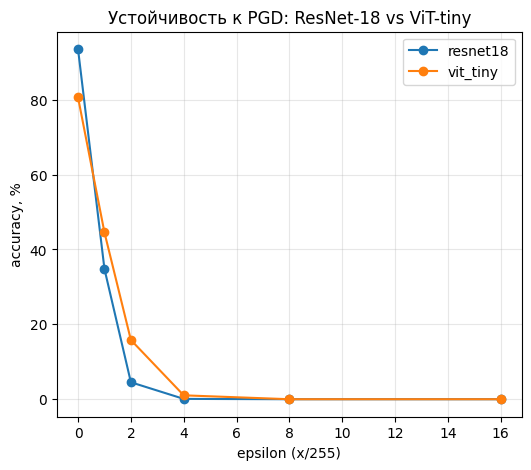

In [19]:
plt.figure(figsize=(6, 5))
for name, accs in pgd_results.items():
    plt.plot(EPS_LIST, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("epsilon (x/255)")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к PGD: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Логирование (PGD)

Итоговая таблица (robust accuracy по каждой модели и eps, PGD):


,eps (x/255),resnet18,vit_tiny
0,0,0.9347,0.8058
1,1,0.3478,0.4454
2,2,0.0453,0.1582
3,4,0.0009,0.0104
4,8,0.0000,0.0000
5,16,0.0000,0.0000


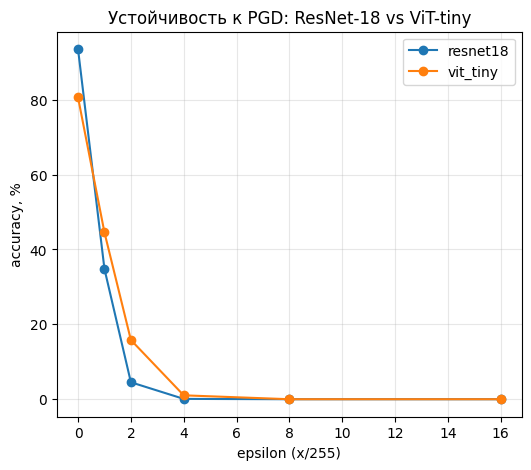

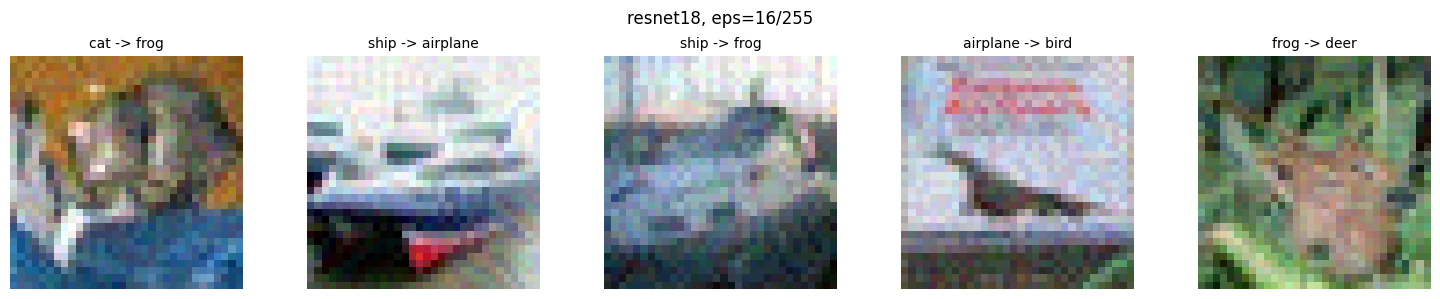

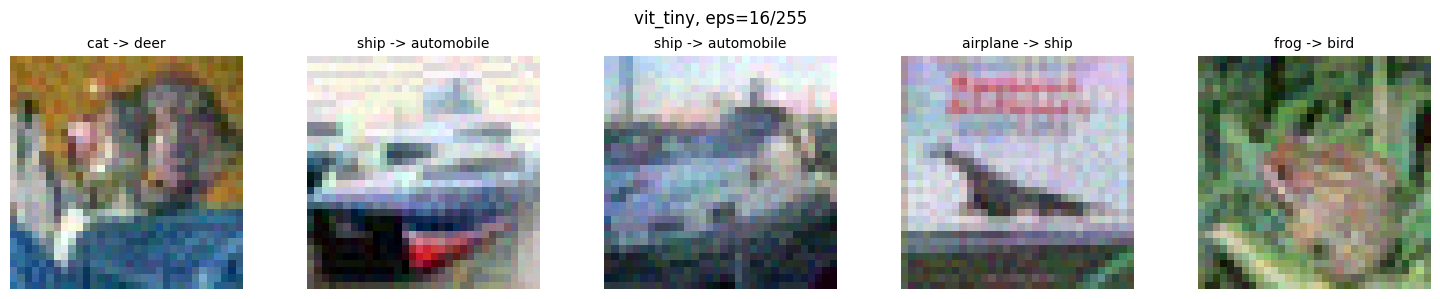

In [20]:

pgd_summary_df = pd.DataFrame({"eps (x/255)": EPS_LIST, **pgd_results})
print("Итоговая таблица (robust accuracy по каждой модели и eps, PGD):")
display(pgd_summary_df)

pgd_fig = plt.figure(figsize=(6, 5))
for name, accs in pgd_results.items():
    plt.plot(EPS_LIST, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("epsilon (x/255)")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к PGD: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pgd_example_figs = {}
for name in models:
    ex_list = pgd_examples[name][EPS_LIST[-1]]
    if not ex_list:
        continue
    ex_fig, axes = plt.subplots(1, len(ex_list), figsize=(3 * len(ex_list), 3))
    axes = [axes] if len(ex_list) == 1 else axes
    for ax, (true_label, pred_label, img) in zip(axes, ex_list):
        ax.imshow(np.transpose(img, (1, 2, 0)).clip(0, 1))
        ax.set_title(f"{CLASSES[true_label]} -> {CLASSES[pred_label]}", fontsize=10)
        ax.axis("off")
    ex_fig.suptitle(f"{name}, eps={EPS_LIST[-1]}/255")
    plt.tight_layout()
    plt.show()
    pgd_example_figs[name] = ex_fig


# try:
#     from clearml import Task
#     task = Task.init(project_name="adversarial-attacks", task_name="pgd-resnet-vs-vit")
#     logger = task.get_logger()
#     for name, accs in pgd_results.items():
#         for eps_num, acc in zip(EPS_LIST, accs):
#             logger.report_scalar(title="robust_accuracy_vs_eps", series=name, iteration=eps_num, value=acc)
#     logger.report_table(title="pgd_comparison", series="summary", iteration=0, table_plot=pgd_summary_df)
#     logger.report_matplotlib_figure(title="accuracy_vs_epsilon", series="comparison", figure=pgd_fig, iteration=0)
#     for name, ex_fig in pgd_example_figs.items():
#         logger.report_matplotlib_figure(title="pgd_examples", series=name, figure=ex_fig, iteration=0)
#     print("\nРезультаты также залогированы в ClearML (project: adversarial-attacks).")
# except Exception as e:
#     print(f"\nClearML недоступен ({e}) — результаты выше видны локально в ноутбуке.")

## One Pixel атака

Чёрный ящик — модель используется только для прямого прохода, градиент не считается вообще (в отличие от FGSM/PGD/Patch). Вместо этого — случайный перебор: пробуем несколько случайных вариантов цвета и расположения нескольких пикселей, оставляем тот, что сильнее всего сбивает уверенность модели в правильном классе, повторяем несколько раундов. Соответствует исходной идее атаки (Su et al., 2019), рассчитанной как раз на сценарий без доступа к градиентам.

Варьируем количество изменяемых пикселей вместо epsilon/размера патча.

In [21]:
class OnePixelAttack:
    def __init__(self, num_pixels=1, num_candidates=50, num_iters=3):
        self.num_pixels = num_pixels
        self.num_candidates = num_candidates
        self.num_iters = num_iters

    def __call__(self, model, x, y):
        B, C, H, W = x.shape
        device = x.device
        batch_idx = torch.arange(B, device=device)
        best = x.clone().detach()

        with torch.no_grad():
            best_conf = F.softmax(model(best), dim=1).gather(1, y.view(-1, 1)).squeeze(1)

        for _ in range(self.num_iters):
            for _ in range(self.num_candidates):
                candidate = best.clone()
                rows = torch.randint(0, H, (B, self.num_pixels), device=device)
                cols = torch.randint(0, W, (B, self.num_pixels), device=device)
                colors = torch.rand(B, self.num_pixels, C, device=device)
                for p in range(self.num_pixels):
                    candidate[batch_idx, :, rows[:, p], cols[:, p]] = colors[:, p, :]

                with torch.no_grad():
                    conf = F.softmax(model(candidate), dim=1).gather(1, y.view(-1, 1)).squeeze(1)

                improved = conf < best_conf
                best[improved] = candidate[improved]
                best_conf = torch.where(improved, conf, best_conf)

        return best.detach()

## Прогон One Pixel атаки для обеих моделей


In [23]:
NUM_PIXELS_LIST = [1, 3, 5]

onepixel_results = {name: [] for name in models}
onepixel_examples = {name: {} for name in models}

for name, m in models.items():
    for n_px in NUM_PIXELS_LIST:
        attack = OnePixelAttack(num_pixels=n_px, num_candidates=50, num_iters=3)
        acc, ex = evaluate_robust_accuracy(m, attack, test_loader, device)
        onepixel_results[name].append(acc)
        onepixel_examples[name][n_px] = ex
        print(f"{name:>10} | pixels={n_px:>2} -> accuracy {acc*100:5.2f}%")

  resnet18 | pixels= 1 -> accuracy  1.16%
  resnet18 | pixels= 3 -> accuracy  0.41%
  resnet18 | pixels= 5 -> accuracy  0.40%
  vit_tiny | pixels= 1 -> accuracy  4.31%
  vit_tiny | pixels= 3 -> accuracy  0.87%
  vit_tiny | pixels= 5 -> accuracy  0.59%


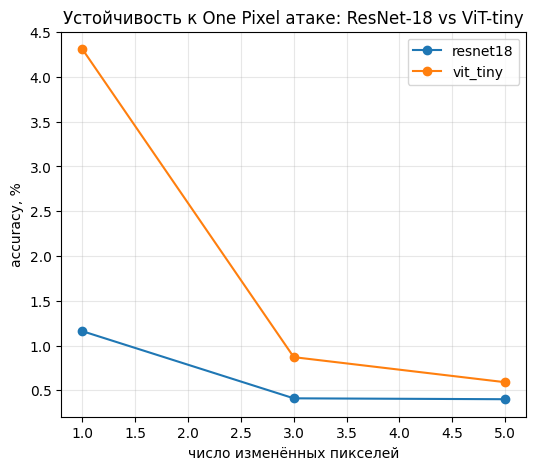

In [ ]:
plt.figure(figsize=(6, 5))
for name, accs in onepixel_results.items():
    plt.plot(NUM_PIXELS_LIST, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("число изменённых пикселей")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к One Pixel атаке: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Логирование (One Pixel)

Итоговая таблица (robust accuracy по каждой модели и числу пикселей):


,num pixels,resnet18,vit_tiny
0,1,0.0116,0.0431
1,3,0.0041,0.0087
2,5,0.0040,0.0059


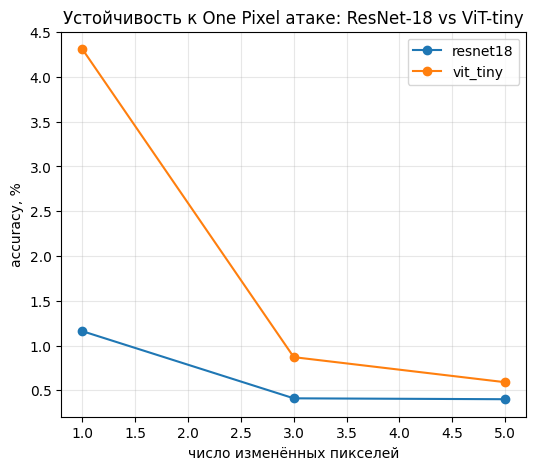

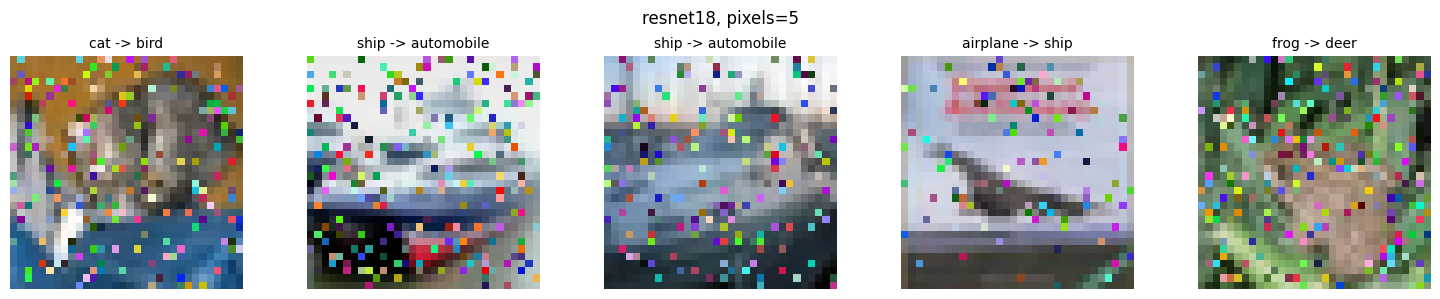

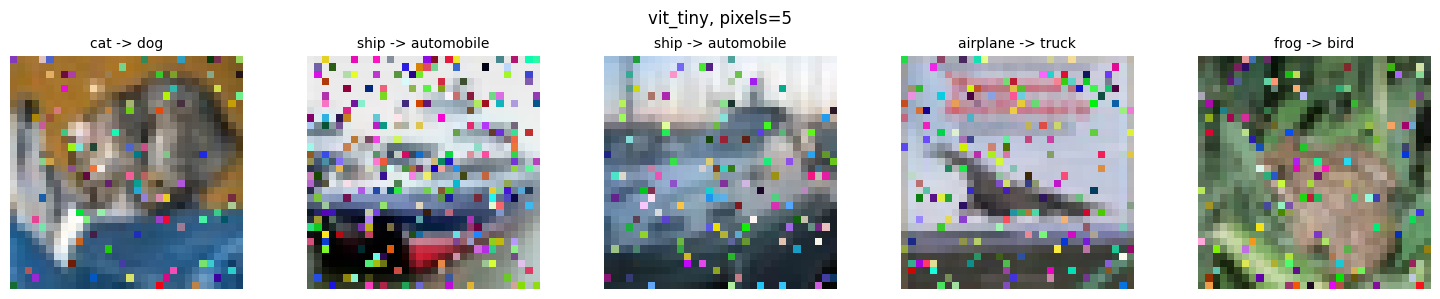

In [ ]:

onepixel_summary_df = pd.DataFrame({"num pixels": NUM_PIXELS_LIST, **onepixel_results})
print("Итоговая таблица (robust accuracy по каждой модели и числу пикселей):")
display(onepixel_summary_df)

onepixel_fig = plt.figure(figsize=(6, 5))
for name, accs in onepixel_results.items():
    plt.plot(NUM_PIXELS_LIST, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("число изменённых пикселей")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к One Pixel атаке: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

onepixel_example_figs = {}
for name in models:
    ex_list = onepixel_examples[name][NUM_PIXELS_LIST[-1]]
    if not ex_list:
        continue
    ex_fig, axes = plt.subplots(1, len(ex_list), figsize=(3 * len(ex_list), 3))
    axes = [axes] if len(ex_list) == 1 else axes
    for ax, (true_label, pred_label, img) in zip(axes, ex_list):
        ax.imshow(np.transpose(img, (1, 2, 0)).clip(0, 1))
        ax.set_title(f"{CLASSES[true_label]} -> {CLASSES[pred_label]}", fontsize=10)
        ax.axis("off")
    ex_fig.suptitle(f"{name}, pixels={NUM_PIXELS_LIST[-1]}")
    plt.tight_layout()
    plt.show()
    onepixel_example_figs[name] = ex_fig


# try:
#     from clearml import Task
#     task = Task.init(project_name="adversarial-attacks", task_name="onepixel-resnet-vs-vit")
#     logger = task.get_logger()
#     for name, accs in onepixel_results.items():
#         for n_px, acc in zip(NUM_PIXELS_LIST, accs):
#             logger.report_scalar(title="robust_accuracy_vs_num_pixels", series=name, iteration=n_px, value=acc)
#     logger.report_table(title="onepixel_comparison", series="summary", iteration=0, table_plot=onepixel_summary_df)
#     logger.report_matplotlib_figure(title="accuracy_vs_num_pixels", series="comparison", figure=onepixel_fig, iteration=0)
#     for name, ex_fig in onepixel_example_figs.items():
#         logger.report_matplotlib_figure(title="onepixel_examples", series=name, figure=ex_fig, iteration=0)
#     print("\nРезультаты также залогированы в ClearML (project: adversarial-attacks).")
# except Exception as e:
#     print(f"\nClearML недоступен ({e}) — результаты выше видны локально в ноутбуке.")

## Patch-атака

Другой тип возмущения, не epsilon-шар по всей картинке, а произвольное по силе возмущение внутри **ограниченной по площади** области — квадратный патч фиксированного размера. Тот же интерфейс `attack(model, x, y) -> x_adv`, поэтому `evaluate_robust_accuracy` ниже переиспользуется без единого изменения.

Патч ставится **по центру** (не в случайном месте) — иначе для честного сравнения пришлось бы отдельно синхронизировать случайное расположение между прогонами на ResNet и ViT, как делали с порядком картинок для FGSM. С фиксированным центром обе модели гарантированно видят одно и то же возмущение в одном и том же месте.

In [ ]:
class PatchAttack:
    def __init__(self, patch_size=8, num_steps=10, step_size=0.1, random_location=False):
        self.patch_size = patch_size
        self.num_steps = num_steps
        self.step_size = step_size
        self.random_location = random_location

    def _make_mask(self, x):
        B, C, H, W = x.shape
        mask = torch.zeros_like(x)
        if self.random_location:
            top = torch.randint(0, H - self.patch_size + 1, (1,)).item()
            left = torch.randint(0, W - self.patch_size + 1, (1,)).item()
        else:
            top = (H - self.patch_size) // 2
            left = (W - self.patch_size) // 2
        mask[:, :, top:top + self.patch_size, left:left + self.patch_size] = 1.0
        return mask

    def __call__(self, model, x, y):
        mask = self._make_mask(x)

        x_adv = x.clone().detach()
        x_adv = x_adv + mask * (torch.rand_like(x) * 2 - 1) * 0.5
        x_adv = x_adv.clamp(0, 1).detach()

        for _ in range(self.num_steps):
            x_adv.requires_grad_(True)
            loss = F.cross_entropy(model(x_adv), y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            # шаг делается только внутри маски — остальная картинка не меняется вообще
            x_adv = x_adv.detach() + self.step_size * grad.sign() * mask
            x_adv = x_adv.clamp(0, 1).detach()

        return x_adv

## Прогон patch-атаки для обеих моделей


In [ ]:
PATCH_SIZES = [2, 4, 8, 12, 16]  # сторона квадрата в пикселях, картинка 32x32

patch_results = {name: [] for name in models}
patch_examples = {name: {} for name in models}

for name, m in models.items():
    for size in PATCH_SIZES:
        attack = PatchAttack(patch_size=size, num_steps=10, step_size=0.1, random_location=False)
        acc, ex = evaluate_robust_accuracy(m, attack, test_loader, device)
        patch_results[name].append(acc)
        patch_examples[name][size] = ex
        print(f"{name:>10} | patch={size:>2}x{size:<2} -> accuracy {acc*100:5.2f}%")

  resnet18 | patch= 2x2  -> accuracy 76.21%
  resnet18 | patch= 4x4  -> accuracy 36.46%
  resnet18 | patch= 8x8  -> accuracy  2.18%
  resnet18 | patch=12x12 -> accuracy  0.00%
  resnet18 | patch=16x16 -> accuracy  0.00%
  vit_tiny | patch= 2x2  -> accuracy 59.17%
  vit_tiny | patch= 4x4  -> accuracy 26.78%
  vit_tiny | patch= 8x8  -> accuracy 11.17%
  vit_tiny | patch=12x12 -> accuracy  0.00%
  vit_tiny | patch=16x16 -> accuracy  0.00%


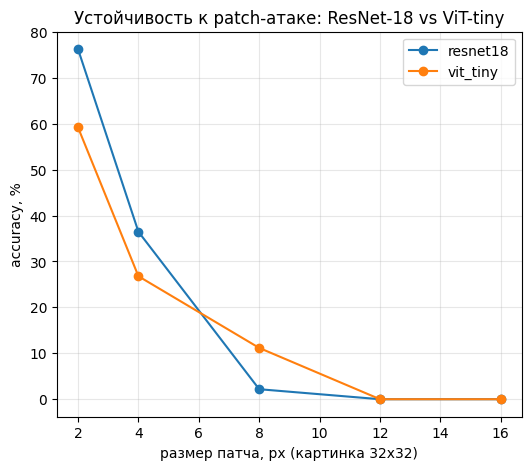

In [ ]:
plt.figure(figsize=(6, 5))
for name, accs in patch_results.items():
    plt.plot(PATCH_SIZES, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("размер патча, px (картинка 32x32)")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к patch-атаке: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Логирование (patch)

Итоговая таблица (robust accuracy по каждой модели и размеру патча):


,"patch size, px",resnet18,vit_tiny
0,2,0.7621,0.5917
1,4,0.3646,0.2678
2,8,0.0218,0.1117
3,12,0.0000,0.0000
4,16,0.0000,0.0000


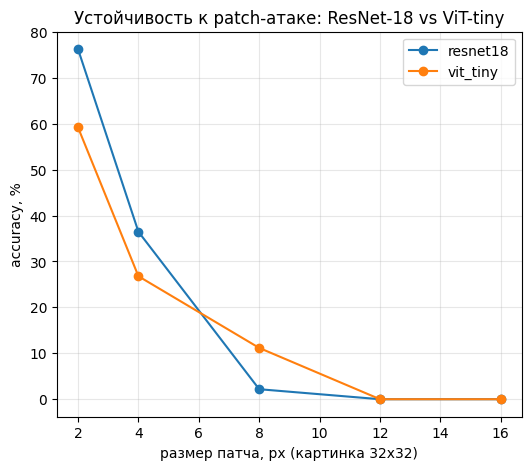

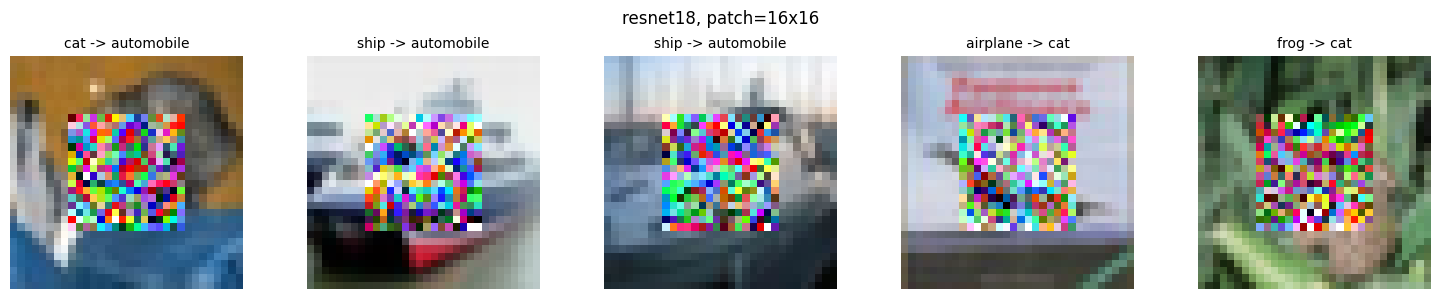

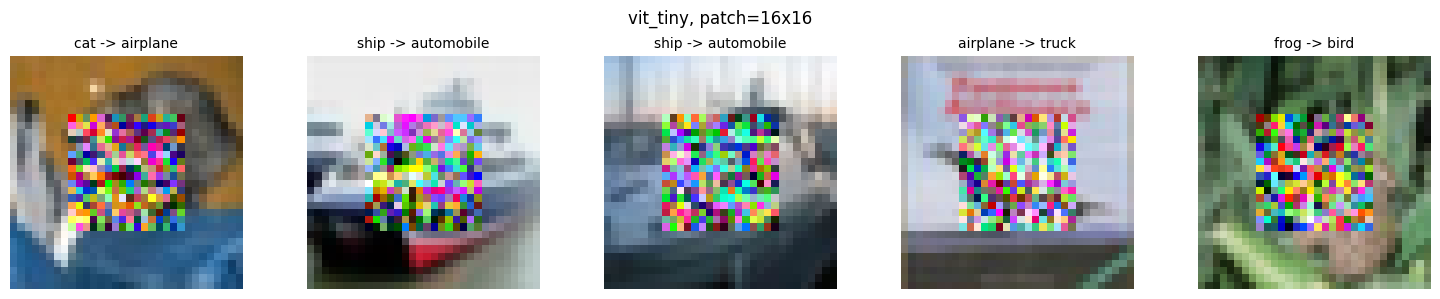

In [ ]:

patch_summary_df = pd.DataFrame({"patch size, px": PATCH_SIZES, **patch_results})
print("Итоговая таблица (robust accuracy по каждой модели и размеру патча):")
display(patch_summary_df)

patch_fig = plt.figure(figsize=(6, 5))
for name, accs in patch_results.items():
    plt.plot(PATCH_SIZES, [a * 100 for a in accs], marker="o", label=name)
plt.xlabel("размер патча, px (картинка 32x32)")
plt.ylabel("accuracy, %")
plt.title("Устойчивость к patch-атаке: ResNet-18 vs ViT-tiny")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

patch_example_figs = {}
for name in models:
    ex_list = patch_examples[name][PATCH_SIZES[-1]]
    if not ex_list:
        continue
    ex_fig, axes = plt.subplots(1, len(ex_list), figsize=(3 * len(ex_list), 3))
    axes = [axes] if len(ex_list) == 1 else axes
    for ax, (true_label, pred_label, img) in zip(axes, ex_list):
        ax.imshow(np.transpose(img, (1, 2, 0)).clip(0, 1))
        ax.set_title(f"{CLASSES[true_label]} -> {CLASSES[pred_label]}", fontsize=10)
        ax.axis("off")
    ex_fig.suptitle(f"{name}, patch={PATCH_SIZES[-1]}x{PATCH_SIZES[-1]}")
    plt.tight_layout()
    plt.show()
    patch_example_figs[name] = ex_fig


# try:
#     from clearml import Task
#     task = Task.init(project_name="adversarial-attacks", task_name="patch-resnet-vs-vit")
#     logger = task.get_logger()
#     for name, accs in patch_results.items():
#         for size, acc in zip(PATCH_SIZES, accs):
#             logger.report_scalar(title="robust_accuracy_vs_patch_size", series=name, iteration=size, value=acc)
#     logger.report_table(title="patch_comparison", series="summary", iteration=0, table_plot=patch_summary_df)
#     logger.report_matplotlib_figure(title="accuracy_vs_patch_size", series="comparison", figure=patch_fig, iteration=0)
#     for name, ex_fig in patch_example_figs.items():
#         logger.report_matplotlib_figure(title="patch_examples", series=name, figure=ex_fig, iteration=0)
#     print("\nРезультаты также залогированы в ClearML (project: adversarial-attacks).")
# except Exception as e:
#     print(f"\nClearML недоступен ({e}) — результаты выше видны локально в ноутбуке.")